# Lecture 1: Linear Models and Linear Algebra

This lecture introduces foundational concepts in machine learning and linear algebra that will recur throughout the course.

#### Setup Instructions

In Google Colab, click **File → Download → Download .ipynb** to save a local copy of the notebook.


**Downloading the data.** Run the following setup cell to download the required data files and place them in a local `data/` directory. To view them, open the Files panel on the left,  then expand 'data', the two downloaded files should appear there. You can then click  the ⋮ (three-dots) next to each file to download it to your local data folder.

After running this cell, all paths used in the notebook (e.g. `data/celer.csv`) should work without modification.


In [ ]:
# Create data directory
import os
os.makedirs("data", exist_ok=True)

# Download required data files
!wget -O data/celer.csv https://github.com/glnmario/PLIN0072-2026/raw/refs/heads/main/Lecture%201/data/celer.csv
!wget -O data/celer_stimuli.txt https://github.com/glnmario/PLIN0072-2026/raw/refs/heads/main/Lecture%201/data/celer_stimuli.txt

--2026-01-13 15:50:19--  https://github.com/glnmario/PLIN0072-2026/raw/refs/heads/main/Lecture%201/data/celer.csv
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/glnmario/PLIN0072-2026/refs/heads/main/Lecture%201/data/celer.csv [following]
--2026-01-13 15:50:19--  https://raw.githubusercontent.com/glnmario/PLIN0072-2026/refs/heads/main/Lecture%201/data/celer.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115288 (113K) [text/plain]
Saving to: ‘data/celer.csv’

data/celer.csv      100%[===================>] 112.59K  --.-KB/s    in 0.008s  

2026-01-13 15:50:19 (13.3 MB/s) - ‘data/celer.csv’ s

## Regression and Classification

In supervised learning, problems are commonly divided into **regression** and **classification**, depending on the type of output the model predicts.
We will examine concrete applications of both regression and classification to the modelling of **psycholinguistic reading behaviour**, using reading times (regression) and word skipping (binary classification) as running examples.


### Regression
In **regression**, the target variable is **continuous**:
$$\mathcal{Y} \subseteq \mathbb{R}$$

The goal is to learn a function:
$$f : \mathbb{R}^d \rightarrow \mathbb{R}$$

Regression models predict real-valued quantities.  
We will look at a canonical example from psycholinguistics, **reading time prediction**, where the model estimates how long a reader spends on a word or region of text.

### Classification
In **classification**, the target variable is **discrete**, drawn from a finite set of labels:
$$\mathcal{Y} = \{1, \dots, K\}$$

The goal is to learn a function:
$$f : \mathbb{R}^d \rightarrow \{1, \dots, K\}$$

We will look at another common example from psycholinguistics, modelling **word skipping**. This is a case of binary classification ($K=2$) where the model predicts whether a word is fixated or skipped during reading.




## Linear Regression

Linear regression is one of the simplest and most widely used supervised learning models.
Its goal is to predict a real-valued output from a fixed set of numerical input features.

Each input is represented as a vector of $d$ real-valued quantities:
$$\mathbf{x}^{(i)} = (x^{(i)}_1, \dots, x^{(i)}_d).$$

The model predicts an output $\widehat{y}^{(i)}$ using a linear function of the inputs:
$$
\widehat{y}^{(i)} = w_0 + \sum_{j=1}^d w_j \, x^{(i)}_j.
$$

The parameters $w_1, \dots, w_d$ are the **weights**, which determine the contribution of each feature.
The parameter $w_0$ is the **intercept**, corresponding to the predicted output when all input features are zero.

The prediction $\widehat{y}^{(i)} \in \mathbb{R}$ is intended to approximate the observed target value $y^{(i)}$.

### Example: Predicting Reading Time

Let's consider a classic regression task from psycholinguistics: predicting the reading time of a word in a sentence, as collected in an eye-tracking experiment.

In eye-tracking research, several standard measures of reading time are used. In this course, we will focus on **total fixation duration**, measured in milliseconds, as the target variable $y$, defined as the sum of the durations of all eye fixations on a word during sentence reading. This measure has a clear and widely accepted interpretation as an index of overall processing difficulty.

As predictors, we will study a small set of **commonly used features** in psycholinguistic modelling that are known to affect fixation duration:

* **Word length**, measured in number of characters: longer words typically receive longer fixations.
* **Word frequency**, estimated from a corpus: less frequent words tend to take longer to process.
* **Contextual predictability**, quantified as surprisal (negative log probability) given the preceding words: less predictable words in the given context generally receive longer fixations.

These variables will serve as running examples of input features in our regression models.

We will use the **CELER** dataset (Berzak et al., 2022) for this analysis.
We work with a pre-processed version of the dataset containing eye-tracking data from L1 readers averaged across participants and augmented with a range of word-level predictors, including word length information, word frequency estimates, and surprisal measures.


Let us first inspect a few example stimuli from the dataset (available in `data/celer_stimuli.txt`).

In [ ]:
with open('data/celer_stimuli.txt', 'r') as f:
    stimuli = f.read().splitlines()

for stimulus in stimuli[:5]:
    print(stimulus)

CNN wants to change its viewers' habits.
Until now, CNN has featured its Hollywood gossip show during the key evening period.
Some in the industry are skeptical.
When you suggest otherwise, you leave the realm of reporting and enter the orbit of speculation.
Sunbelt foreclosed on the ranch.


Now we take a look at the dataset, focusing on the **reading behaviour target variables** and the **predictors** that will be used in our models.

In [ ]:
import pandas as pd

celer = pd.read_csv('data/celer.csv')
celer.head()

,stimulus_id,word_position,word,word_clean,length,length_prev,length_prevprev,frequency,frequency_prev,frequency_prevprev,total_fixation_duration,skip_rate,surprisal_first3chars,surprisal_word,surprisal_word_prev,surprisal_word_prevprev
0,1,0,CNN,cnn,3.0,0.0,0.0,4.28,0.00,0.00,288.81250,0.00000,8.930352,9.361813,0.000000,0.000000
1,1,1,wants,wants,5.0,3.0,0.0,5.24,4.28,0.00,512.37500,0.21875,6.323333,6.812132,9.361813,0.000000
2,1,2,to,to,2.0,5.0,3.0,7.43,5.24,4.28,138.21875,0.78125,0.455620,0.455620,6.812132,9.361813
3,1,3,change,change,6.0,2.0,5.0,5.54,7.43,5.24,381.78125,0.06250,3.982607,4.222057,0.455620,6.812132
4,1,4,its,its,3.0,6.0,2.0,6.14,5.54,7.43,148.53125,0.62500,2.346851,2.353975,4.222057,0.455620


The dataset contains the following entries:

* **`stimulus_id`**: Identifier of the sentence in which the word appears.

* **`word_position`**: Position of the word within the sentence.

* **`word`**: The word as it appears in the stimulus.

* **`word_clean`**: A normalised version of the word (lowercased and stripped of punctuation).

* **`length`**: Length of the current word, measured in number of characters.

* **`length_prev`**: Length of the immediately preceding word.

* **`length_prevprev`**: Length of the word two positions before the current word.

* **`frequency`**: Corpus-based word frequency, expressed on the Zipf scale (explained later).

* **`frequency_prev`**: Zipf frequency of the immediately preceding word.

* **`frequency_prevprev`**: Zipf frequency of the word two positions before the current word.

* **`total_fixation_duration`**: Total fixation time on the word (in milliseconds), summed across all fixations.

* **`skip_rate`**: Proportion of trials in which the word was skipped (i.e. not fixated).

* **`surprisal_first3chars`**: Surprisal of the first three characters of the word, reflecting early orthographic predictability.

* **`surprisal_word`**: Surprisal of the full word given its preceding context.

* **`surprisal_word_prev`**: Surprisal of the immediately preceding word.

* **`surprisal_word_prevprev`**: Surprisal of the word two positions before the current word.

The `prev` and `prevprev` variables allow us to account for **spillover effects**, where processing difficulty associated with one word influences reading behaviour on subsequent words.

Reading is not strictly instantaneous or word-by-word. If a word is long, rare, or unexpected, some of its processing may continue after the eyes have moved on, leading to increased fixation times or changes in skipping behaviour on the following word, or even the word after that.

For this reason, psycholinguistic models often include predictors derived from **previous words**, such as their length, frequency, or surprisal. Including these variables helps capture delayed effects of lexical and contextual difficulty, rather than attributing all observed behaviour solely to the currently fixated word.



#### Input variables

Let us inspect the distributions of the predictor variables: **word length**, **word frequency**, and **word surprisal**.

**Zipf frequency** is a variant of word frequency designed to be more interpretable by using a logarithmic scale. Formally, it is the base-10 logarithm of the number of times a word occurs per **billion** tokens. For example, a Zipf value of **6** corresponds to roughly one occurrence per **thousand** words, while a value of **3** corresponds to roughly one occurrence per **million** words. In this course, Zipf frequencies are computed using the [**wordfreq** library](https://pypi.org/project/wordfreq/).

**Surprisal** is estimated using the GPT-2 language model, with values taken from [Giulianelli et al. 2024](https://aclanthology.org/2024.emnlp-main.1032/).
Surprisal is computed at the character level and then aggregated to the word level. Concretely, the surprisal of a word corresponds to the negative log probability of its character sequence given the preceding context, for example:
$$
-\log p(\text{``to ''} \mid \text{``CNN wants ''})
= -\log \bigl(p(\text{``t''}\mid \text{``CNN wants ''}) \cdot p(\text{``o''}\mid \text{``CNN wants t''}) \cdot p(\text{`` ''}\mid \text{``CNN wants to''})\bigr).
$$


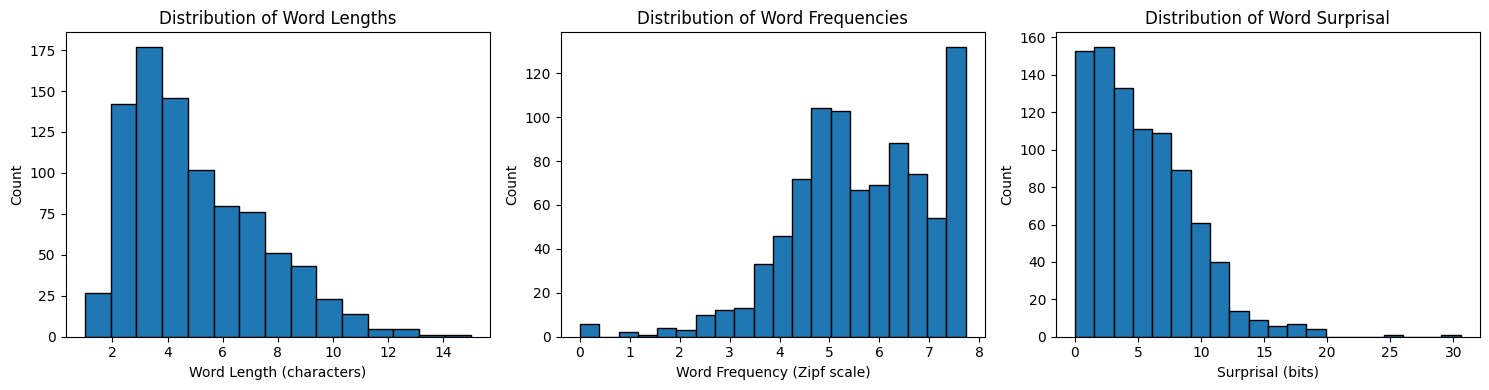

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot distribution of word lengths
axes[0].hist(celer['length'], bins=len(celer['length'].unique()), edgecolor='black')
axes[0].set_xlabel('Word Length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Word Lengths')

# Plot distribution of word frequencies
axes[1].hist(celer['frequency'], bins=20, edgecolor='black')
axes[1].set_xlabel('Word Frequency (Zipf scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Word Frequencies')

# Plot distribution of surprisal values
axes[2].hist(celer['surprisal_word'], bins=20, edgecolor='black')
axes[2].set_xlabel('Surprisal (bits)')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribution of Word Surprisal')

plt.tight_layout()
plt.show()

#### Output variable

We now turn to the output variable, **total fixation time**, which measures the total amount of time (in milliseconds) that a reader’s gaze remains on a given word, summed across all fixations during sentence reading. *This is an average across participants.*


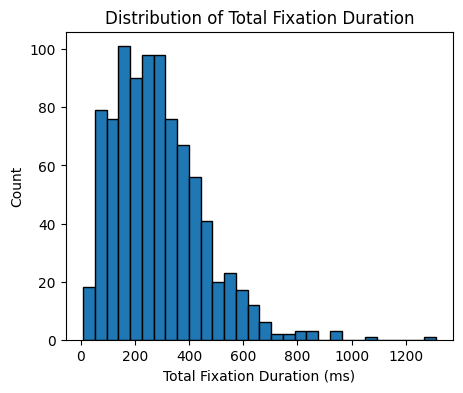

In [ ]:
plt.figure(figsize=(5, 4))
plt.hist(celer['total_fixation_duration'], bins=30, edgecolor='black')
plt.xlabel('Total Fixation Duration (ms)')
plt.ylabel('Count')
plt.title('Distribution of Total Fixation Duration')
plt.show()


For a given word $i$, the input representation can be written as
$$
\mathbf{x}^{(i)} = (\text{length}^{(i)}, \text{frequency}^{(i)}, \text{surprisal}^{(i)}).
$$

This corresponds to a vector of numerical predictors extracted for that word.
For example, the feature vector $\mathbf{x}^{(0)}$ for the first word in the dataset can be obtained as follows:



In [ ]:
word_features = celer.loc[0, ['length', 'frequency', 'surprisal_word']].values
[float(x) for x in word_features]

[3.0, 4.28, 9.361813321630011]

For the same word $i$, the output variable is the observed reading time:
$$y^{(i)} = \text{total_fixation_duration}^{(i)}.$$

This is the target value that the regression model aims to predict.
For example, the output value $y^{(0)}$ for the first word in the dataset can be obtained as follows:

In [ ]:
word_target = celer.loc[0, 'total_fixation_duration']
float(word_target)


288.8125

#### Train-test split

We now construct the input matrix **X** and the target vector **y** for our regression model.  
The input features are word length, word frequency, and word surprisal, while the target variable is total fixation duration.

To evaluate the model’s ability to generalise to unseen data, we split the dataset into **training** and **test** sets:

- The **training set** (80%) is used to estimate the model parameters.
- The **test set** (20%) is held out and used only for evaluation, providing an unbiased estimate of predictive performance on new data.

The split is performed randomly, with a fixed random seed to ensure reproducibility.


In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = celer[['length', 'frequency', 'surprisal_word']].values
y = celer['total_fixation_duration'].values

# Create random train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
X_train

array([[ 2.        ,  6.91      ,  5.8346337 ],
       [ 4.        ,  4.45      , 10.94095968],
       [ 9.        ,  5.08      ,  8.68492025],
       ...,
       [ 7.        ,  4.03      ,  2.90226862],
       [ 8.        ,  4.21      ,  5.66015377],
       [ 2.        ,  6.54      ,  3.01584623]])

In [ ]:
print('First input-target pair in training set (after shuffling):')
print('Input features:', X_train[0])
print('Target value:', y_train[0])


First input-target pair in training set (after shuffling):
Input features: [2.        6.91      5.8346337]
Target value: 226.46875


#### Scaling input features (standardisation / z-score)

When input features have very different value ranges, it is common to **standardise** them so they are comparable. Standardisation centres each feature to have **zero mean** and **unit standard deviation**.

For feature $j$ (e.g., frequency) with $N$ observations:

$$
\mu_j = \frac{1}{N} \sum_{i=1}^{N} x_j^{(i)} \qquad \sigma_j = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left(x_j^{(i)} - \mu_j\right)^2}
$$

Each value is then transformed as:

$$
x_j^{(i)\prime} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}
$$

After standardisation, all features have mean 0 and standard deviation 1.

> **Important:** In a supervised learning setting, the mean ( $\mu_j$ ) and standard deviation ( $\sigma_j$ ) must be computed **using the training data only**. The same values are then used to standardise validation and test data. Computing these statistics on the full dataset (or separately on the test set) would leak information from the test data into training and lead to overly optimistic evaluation.


----
In our example, standardisation is not strictly necessary because the input features already have similar value ranges. We nevertheless apply standardisation, as it makes feature weights easier to compare.

In [ ]:
# Compute mean and std from training set only
features = ['length', 'frequency', 'surprisal_word']

# Compute mean and std from training set only
train_means = X_train.mean(axis=0)  # shape (3,), i.e., one mean per feature
train_stds = X_train.std(axis=0)    # shape (3,), i.e., one std per feature

# Apply standardization to both sets using training statistics
X_train = (X_train - train_means) / train_stds
X_test = (X_test - train_means) / train_stds

print("Training set statistics (computed from training data):")
for i, feature in enumerate(features):
    print(f"  {feature}: mean = {train_means[i]:.4f}, std = {train_stds[i]:.4f}")

print("\nStandardized training set statistics:")
print(f"  Mean: {X_train.mean(axis=0)}")
print(f"  Std:  {X_train.std(axis=0)}")

print("\nStandardized test set statistics (using training transformation):")
print(f"  Mean: {X_test.mean(axis=0)}")
print(f"  Std:  {X_test.std(axis=0)}")


# -----------------------------
# Alternatively standardise using sklearn
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# -----------------------------

Training set statistics (computed from training data):
  length: mean = 4.8095, std = 2.5717
  frequency: mean = 5.6071, std = 1.4527
  surprisal_word: mean = 5.3992, std = 4.0935

Standardized training set statistics:
  Mean: [ 9.36070393e-17 -3.85794726e-15  1.55493421e-17]
  Std:  [1. 1. 1.]

Standardized test set statistics (using training transformation):
  Mean: [-0.03020593  0.05482619 -0.03930172]
  Std:  [0.98951187 0.86338263 0.83775053]


#### Training a linear regression model

We now train a **linear regression** model on the training data. We will use an existing model from the [sci-kit learn](https://scikit-learn.org) library, a Python library with common machine learning methods.

The model learns a set of weights that minimise the squared difference between the predicted reading times and the observed total fixation durations in the training set.

Once trained, the model can be used to generate predictions for both the training data and the held-out test data.


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialise the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Generate predictions on the test set
y_test_pred = model.predict(X_test)


#### Mean squared error (MSE)

To evaluate how well the model’s predictions match the observed reading times, we use the **mean squared error (MSE)**.
MSE measures the average squared difference between predicted and true values and is defined as:
$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^N (\widehat{y}^{(i)} - y^{(i)})^2,
$$
where $N$ is the number of test examples, $\widehat{y}^{(i)}$ is the model’s prediction, and $y^{(i)}$ is the observed value. The squaring operation penalises larger errors more strongly. Lower MSE values indicate better predictive performance.


In [ ]:
# Define MSE manually
import numpy as np

# Define MSE function
def mse(y_true, y_pred):
    total_error = 0.0
    N = len(y_true)
    for i in range(N):
        error = y_pred[i] - y_true[i]
        total_error += error ** 2
    return total_error / N

# Equivalent NumPy implementation
# def mse_numpy(y_true, y_pred):
#     return np.mean((y_pred - y_true) ** 2)

# Compute MSE using our function
mse_test_manual = mse(y_test, y_test_pred)
mse_test_manual


np.float64(11877.354380125402)

In [ ]:
# Compute MSE using sklearn
from sklearn.metrics import mean_squared_error

mse_test_sklearn = mean_squared_error(y_test, y_test_pred)
mse_test_sklearn


11877.354380125398

The MSE is expressed in squared milliseconds, because the target variable (total fixation duration) is measured in milliseconds. To interpret the error on the original scale, we need to take the square root of the MSE, i.e., the **root mean squared error (RMSE)**:
$$
\text{RMSE} = \sqrt{\text{MSE}}.
$$


In [ ]:
rmse_test = np.sqrt(mse_test_sklearn)
print('On average, our model makes an error of about')
print(f'{rmse_test:.2f} milliseconds')
print('when predicting total fixation duration on the test set.')

On average, our model makes an error of about
108.98 milliseconds
when predicting total fixation duration on the test set.


To assess model performance, we can also visualise the relationship between the model’s predictions and the observed reading times. The scatter plot below shows predicted values on the x-axis and actual values on the y-axis.

The diagonal line corresponds to perfect predictions: points lying exactly on this line indicate that the predicted and actual reading times are equal. The closer the points cluster around the diagonal, the more accurate the model’s predictions.


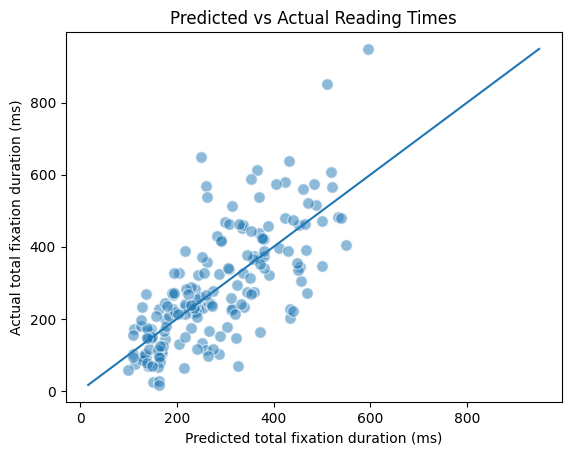

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of predicted vs actual values
plt.figure()
plt.scatter(y_test_pred, y_test, alpha=0.5, edgecolors='w', s=70)
plt.xlabel("Predicted total fixation duration (ms)")
plt.ylabel("Actual total fixation duration (ms)")
plt.title("Predicted vs Actual Reading Times")

# Optional reference line: perfect prediction
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


#### Comparing models with and without surprisal

We now compare the full model to a simpler baseline that excludes surprisal and uses only word length and word frequency as predictors.

We train a second linear regression model on these reduced features, evaluate its performance using mean squared error on the same test set, and compare it to the MSE of the full model. This allows us to assess the contribution of surprisal to predictive accuracy.

In addition, we visualise the predictions of the reduced model by plotting predicted versus actual reading times, using the same format as before.

In [ ]:
# -----------------------------
# Full model (length, frequency, surprisal), same as above
# -----------------------------
X_full = celer[['length', 'frequency', 'surprisal_word']].values
y = celer['total_fixation_duration'].values

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=0
)

# Standardise features
from sklearn.preprocessing import StandardScaler
scaler_full = StandardScaler()
X_train_full = scaler_full.fit_transform(X_train_full)
X_test_full = scaler_full.transform(X_test_full)

model_full = LinearRegression()
model_full.fit(X_train_full, y_train)
y_test_pred_full = model_full.predict(X_test_full)

mse_full = mean_squared_error(y_test, y_test_pred_full)

# -----------------------------
# Reduced model (length, frequency)
# -----------------------------
X_reduced = celer[['length', 'frequency']].values

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=0
)

# Standardise features
scaler_reduced = StandardScaler()
X_train_red = scaler_reduced.fit_transform(X_train_red)
X_test_red = scaler_reduced.transform(X_test_red)

model_reduced = LinearRegression()
model_reduced.fit(X_train_red, y_train_red)
y_test_pred_reduced = model_reduced.predict(X_test_red)

mse_reduced = mean_squared_error(y_test_red, y_test_pred_reduced)

# -----------------------------
# MSE
# -----------------------------
print(f"MSE (full: length + frequency + surprisal): {mse_full:.4f}")
print(f"MSE (reduced: length + frequency):          {mse_reduced:.4f}")
print(f"Improvement in MSE by adding surprisal:     {mse_reduced - mse_full:.4f}")

# -----------------------------
# RMSE (in milliseconds)
# -----------------------------
rmse_full = np.sqrt(mse_full)
rmse_reduced = np.sqrt(mse_reduced)
print(f"\nRMSE (full: length + frequency + surprisal): {rmse_full:.2f} ms")
print(f"RMSE (reduced: length + frequency):          {rmse_reduced:.2f} ms")
print(f"Improvement in RMSE by adding surprisal:     {rmse_reduced - rmse_full:.2f} ms")
print(f"Error reduction percentage:                  {100 * (rmse_reduced - rmse_full) / rmse_reduced:.2f}%")


MSE (full: length + frequency + surprisal): 11877.3544
MSE (reduced: length + frequency):          13639.5216
Improvement in MSE by adding surprisal:     1762.1673

RMSE (full: length + frequency + surprisal): 108.98 ms
RMSE (reduced: length + frequency):          116.79 ms
Improvement in RMSE by adding surprisal:     7.81 ms
Error reduction percentage:                  6.68%


#### Inspecting feature weights in the full linear regression model

Recall that in linear regression, the prediction for an input vector $\mathbf{x}^{(i)} \in \mathbb{R}^d$ takes the form
$
\widehat{y}^{(i)} = w_0 + \sum_{j=1}^d w_j \, x^{(i)}_j.
$
For the full model, we use the three features
$
\mathbf{x}^{(i)} = (\text{length}^{(i)}, \text{frequency}^{(i)}, \text{surprisal}^{(i)}),
$
so the learned parameter vector is
$$
\mathbf{w} = (w_{\text{length}}, w_{\text{frequency}}, w_{\text{surprisal}}).
$$

We now inspect the fitted weights $\mathbf{w}$ (and the intercept $w_0$) learned from the training data. Each weight $w_j$ indicates how the prediction changes as the corresponding feature increases by one unit, *holding the other features fixed*.

- A **positive** weight increases $\widehat{y}^{(i)}$ as the feature increases.
- A **negative** weight decreases $\widehat{y}^{(i)}$ as the feature increases.
- The **magnitude** reflects the strength of the association, but interpretation depends on the feature’s scale (e.g., length in characters vs. Zipf frequency vs. surprisal).

-----

We look here at the full model with three predictors.

In [ ]:
feature_names = ['length', 'frequency', 'surprisal_word']

print(f"Intercept w_0:   {float(model_full.intercept_):+2.2f}")
print("\nWeights:")
for name, w in zip(feature_names, model_full.coef_):
    print(f"  {name:>14s}: {float(w):+2.2f}")


Intercept w_0:   +284.66

Weights:
          length: +63.36
       frequency: -41.52
  surprisal_word: +41.83


##### How to intepret this?

Because the features were standardised, each coefficient corresponds to a **one standard deviation increase** in that feature. A one-SD increase means increasing a feature by the amount it typically varies in the data (one standard deviation), not by one raw unit (e.g., not one character or one frequency count).

For example, we saw that word length has a standard deviation of 2.5 characters, so a one-SD increase in length means increasing word length by about 2.5 characters increases predicted reading time by about 69 milliseconds, which is roughly 27 ms per character.


**If the features had not been standardised**, each coefficient would correspond to a one-unit increase in the raw feature, and the interpretation would change. For example, the coefficient for *length* would give the change in reading time for one additional character. (You can verify this by retraining the model without standardisation; the coefficient should be approximately 27.)

In that case, however, coefficients are **not directly comparable across features**, because they are expressed in different units. For instance, if we had included raw frequency counts (which can be in the thousands or higher) instead of Zipf frequencies, the corresponding coefficients would be numerically much smaller simply because the unit of measurement is smaller, not because frequency has a weaker effect.


#### Manual application of linear regression to a single test example
For a single test example $i$, we can compute the prediction $\widehat{y}^{(i)}$ manually by taking the dot product between $\mathbf{w}$ and $\mathbf{x}^{(i)}$, adding the intercept $w_0$, and then compare the result to `model_full.predict`.


For a single test example $i$, we can compute the prediction $\widehat{y}^{(i)}$ manually as
$$
\widehat{y}^{(i)} = w_0
+ w_{\text{length}} \cdot \text{length}^{(i)}
+ w_{\text{frequency}} \cdot \text{frequency}^{(i)}
+ w_{\text{surprisal}} \cdot \text{surprisal}^{(i)}.
$$


In [ ]:
# Pick a single test example (first item in the test set)
x_i = X_test_full[0]
y_true_i = y_test[0]

w0 = model_full.intercept_
w = model_full.coef_

# Manual prediction using an explicit sum
y_hat_manual = float(
    w0
    + w[0] * x_i[0]
    + w[1] * x_i[1]
    + w[2] * x_i[2]
)

# Model prediction using sklearn's predict method (expects a 2D array, so we reshape x_i)
# y_hat_model = float(model_full.predict(x_i.reshape(1, -1))[0])

print("Test example features x^(i):", [float(v) for v in x_i])
print(f"Observed y^(i):              {float(y_true_i):+3.2f}")
print(f"Manual prediction y_hat^(i): {y_hat_manual:+3.2f}")
# print(f"model.predict prediction:    {y_hat_model:+3.2f}")
print(f"Difference:                  {(y_hat_manual - y_true_i):+3.2f}")
print(f"Squared difference:          {(y_hat_manual - y_true_i) ** 2:+3.2f}")

Test example features x^(i): [0.46291627401247504, -0.2733278965497532, 0.24079834202732875]
Observed y^(i):              +453.16
Manual prediction y_hat^(i): +335.42
Difference:                  -117.74
Squared difference:          +13862.26


## Logistic Regression

Linear regression predicts a continuous outcome (such as reading time).
Logistic regression adapts the same basic idea to **binary classification**, where the target variable takes one of two values (e.g., 0 or 1).

As before, we start from an input representation
$\mathbf{x}^{(i)} = (x^{(i)}_1, \dots, x^{(i)}_d)$
and compute a linear score $z^{(i)} = w_0 + \sum_{j=1}^{d} w_j \, x^{(i)}_j$.

This score can take any real value, so it is not directly interpretable as a probability.
Logistic regression converts it into a probability using the **logistic (sigmoid)** function
$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The output $\sigma(z^{(i)})$ is interpreted as the probability of the positive class.
A binary prediction is obtained by applying a threshold (typically $0.5$):
$$
\widehat{y}^{(i)} =
\begin{cases}
1 & \text{if } \sigma(z^{(i)}) \ge 0.5,\\
0 & \text{otherwise.}
\end{cases}
$$

### The logistic (sigmoid) function

The sigmoid function maps any real-valued input to a value between 0 and 1, making it well-suited for modelling probabilities in binary classification.


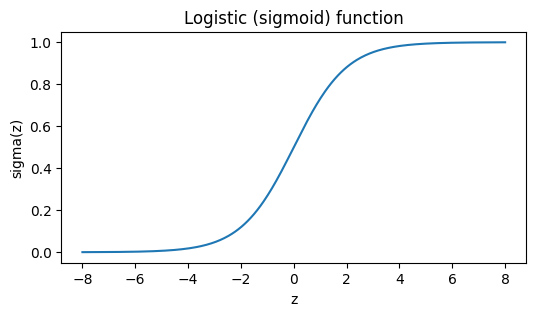

In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Let's take some values for z, e.g., from -8 to 8 (400 points)
z = np.linspace(-8, 8, 400)

# Apply the sigmoid function
sigma_z = sigmoid(z)

# Plot the sigmoid function
plt.figure(figsize=(6, 3))
plt.plot(z, sigma_z)
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("Logistic (sigmoid) function")
plt.ylim(-0.05, 1.05)
plt.show()


### Example: Predicting word skipping

Suppose we want to predict whether a word is skipped during reading.
In eye-tracking studies, skipping is often defined as no fixation on a word during the first pass on that word.

The dataset provided above encode skipping information as a **skip rate**: the proportion of readers who skipped a word. Here we create a binary label by setting
- $y = 1$ if the skip rate is at least $0.5$, and
- $y = 0$ otherwise.

This means that we consider a word as skipped if 50% or more of the participants do not fixate on it at first pass.

> Note how this threshold maps exactly to the decision rule of the logistic regression model. Nonetheless, in a typical analysis, we would model **individual readers' skipping behaviour** rather than thresholding an aggregate skip rate, but for us to do that analysis meaningfully, we would need reader-level predictors, which we don't have.

In [ ]:
# Create a binary skip variable from skip rate (arbitrary threshold at 0.5)
celer['skip_binary'] = (celer['skip_rate'] >= 0.5).astype(int)

celer[['skip_rate', 'skip_binary']].head()

,skip_rate,skip_binary
0,0.00000,0
1,0.21875,0
2,0.78125,1
3,0.06250,0
4,0.62500,1


#### Output variable

We visualise (1) the distribution of skip rates and (2) the resulting binary variable used for classification.

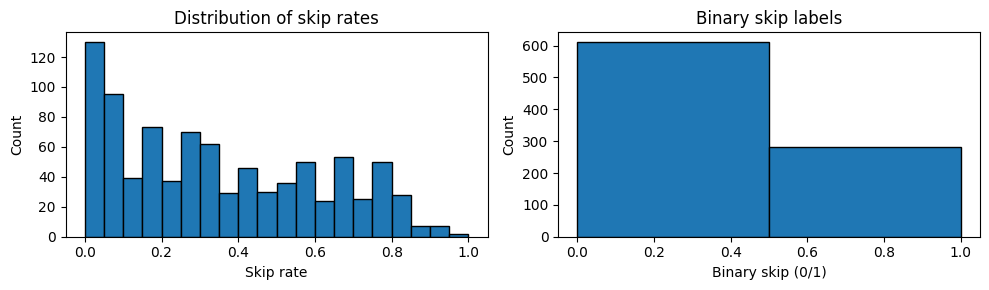

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Skip rate distribution
axes[0].hist(celer['skip_rate'], bins=20, edgecolor='black')
axes[0].set_xlabel('Skip rate')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of skip rates')

# Binary skip distribution
axes[1].hist(celer['skip_binary'], bins=2, edgecolor='black')
axes[1].set_xlabel('Binary skip (0/1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Binary skip labels')

plt.tight_layout()
plt.show()


In [ ]:
# Percentage of words that were skipped
skip_percentage = celer['skip_binary'].mean() * 100
print(f"Percentage of words that were skipped by at least 50% of the participants: {skip_percentage:.2f}%")

Percentage of words that were skipped by at least 50% of the participants: 31.58%


#### Input variables

We will build two logistic regression models:

1. **Word surprisal model**: length, frequency, and word surprisal (`surprisal_word`)
2. **First-3-characters surprisal model**: length, frequency, and surprisal of the first three characters (`surprisal_first3chars`)

> **Why the surprisal of the first three characters?** Research on reading shows that people do not need to see an entire word to begin recognising it: the first few letters often provide enough information to strongly constrain what the word is likely to be. In particular, seeing just the first three characters can already make a word easier to recognise, even if the rest of the word is unclear or briefly unseen. This early partial information can influence simple reading decisions, such as whether a word is likely to be processed quickly or skipped altogether. For this reason, the predictability (surprisal) of the first three characters provides a useful, intuitively motivated measure of how informative the earliest part of a word is. See [Giulianelli et al. 2024](https://aclanthology.org/2024.emnlp-main.1032/) for more details.

#### Train-test split

We now construct an input matrix **X** and the target vector **y** for our two regression models.  As we did for linear regression, we use a random 80-20 training-test split to evaluate the models.

Importantly, we use the same split for both models so that we evaluate both on the same test set. This ensures results are comparable.

In [ ]:
# Target labels
y = celer['skip_binary'].values

# Feature sets for the two models
X_word = celer[['length', 'frequency', 'surprisal_word']].values
X_first3 = celer[['length', 'frequency', 'surprisal_first3chars']].values

# Use the same split for both models by splitting indices once
idx = np.arange(len(celer))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=0)

# Prepare training set for the word-based model
X_train_word, X_test_word = X_word[idx_train], X_word[idx_test]

# Prepare training set for the first-3-chars-based model
X_train_first3, X_test_first3 = X_first3[idx_train], X_first3[idx_test]

# Target labels for both models
y_train, y_test = y[idx_train], y[idx_test]

# Standardise features
word_scaler = StandardScaler()
X_train_word = word_scaler.fit_transform(X_train_word)
X_test_word = word_scaler.transform(X_test_word)

first3_scaler = StandardScaler()
X_train_first3 = first3_scaler.fit_transform(X_train_first3)
X_test_first3 = first3_scaler.transform(X_test_first3)


#### Training a logistic regression model

We now train a **logistic regression** model on the training data. As before, we use an existing implementation from the [scikit-learn](https://scikit-learn.org) library, specifically `sklearn.linear_model.LogisticRegression`.

The model learns a set of weights that determine how strongly each input feature contributes to the probability that a word is skipped. During training, these weights are chosen to best separate skipped from non-skipped words in the training set.

Once trained, the model can be used to compute predicted probabilities of skipping for both the training data and the held-out test data. To obtain concrete binary predictions, we convert these probabilities into binary outcomes by applying a fixed threshold of $0.5$: probabilities above this value are predicted as "skipped", and probabilities below it as "fixated".


In [ ]:
from sklearn.linear_model import LogisticRegression

# Model using word surprisal
logreg_word = LogisticRegression(max_iter=2000, solver='liblinear')
logreg_word.fit(X_train_word, y_train)

# Predicted probabilities for the positive class
p_test_word = logreg_word.predict_proba(X_test_word)[:, 1]

# Convert probabilities to binary predictions (threshold at 0.5)
y_hat_test_word = (p_test_word >= 0.5).astype(int)

# Display first 5 predictions
for _p, y_hat in zip(p_test_word[:5], y_hat_test_word[:5]):
    print(f"Predicted probability: {_p:.4f}, Predicted class: {y_hat}")


Predicted probability: 0.0316, Predicted class: 0
Predicted probability: 0.6766, Predicted class: 1
Predicted probability: 0.0004, Predicted class: 0
Predicted probability: 0.6817, Predicted class: 1
Predicted probability: 0.9119, Predicted class: 1


#### Accuracy

To evaluate how well the model’s predictions match the observed skipping behaviour, we use **accuracy**.
Accuracy measures the proportion of examples for which the predicted label matches the true label and is defined as
$$
\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[\widehat{y}^{(i)} = y^{(i)}],
$$
where $N$ is the number of test examples, $\widehat{y}^{(i)}$ is the model’s predicted class (0 or 1), and $y^{(i)}$ is the observed class.
The indicator function $\mathbb{1}[\cdot]$ equals $1$ when the prediction is correct and $0$ otherwise.
Accuracy therefore takes values between $0$ and $1$, with higher values indicating better classification performance.

As with MSE earlier, we will first implement accuracy manually to make its definition explicit.

In [ ]:
# Define accuracy manually
def accuracy(y_true, y_pred):
    correct = 0
    N = len(y_true)
    for i in range(N):
        if int(y_true[i]) == int(y_pred[i]):
            correct += 1
    return correct / N

acc_word = accuracy(y_test, y_hat_test_word)
acc_word


0.8379888268156425

In [ ]:
# Accuracy using sklearn
from sklearn.metrics import accuracy_score
acc_word_sklearn = accuracy_score(y_test, y_hat_test_word)
acc_word_sklearn

0.8379888268156425

#### Comparing models: word surprisal vs first-3-characters surprisal

We now train the second model and compare their test accuracies.


In [ ]:
# Model using surprisal of the first three characters
logreg_first3 = LogisticRegression(max_iter=2000, solver='liblinear')
logreg_first3.fit(X_train_first3, y_train)

p_test_first3 = logreg_first3.predict_proba(X_test_first3)[:, 1]
y_hat_test_first3 = (p_test_first3 >= 0.5).astype(int)

acc_first3 = accuracy(y_test, y_hat_test_first3)

print(f"Accuracy (length + frequency + surprisal_word):        {acc_word:.3f}")
print(f"Accuracy (length + frequency + surprisal_first3chars): {acc_first3:.3f}")


Accuracy (length + frequency + surprisal_word):        0.838
Accuracy (length + frequency + surprisal_first3chars): 0.855


#### Inspecting feature weights

As in linear regression, logistic regression learns one weight per feature (plus an intercept), but there is an important difference in how to interpret the weights.

Logistic regression first computes a linear score
$
z = w_0 + \sum_{j=1}^{d} w_j x_j.
$
This score is not a probability. It is easiest to interpret it in terms of what is typically referred to as "odds". If the model assigns probability $p$ to the positive class, then the "odds" of the positive class are
$$
\frac{p}{1-p}.
$$
This ratio compares how likely the event is ($p$) to how unlikely it is ($1-p$). So, for example:

* if $p = 0.5$, then $\frac{p}{1-p} = 1$ (equally likely as not);
* if $p = 0.8$, then $\frac{p}{1-p} = 4$ (four times more likely than not);
* if $p = 0.2$, then $\frac{p}{1-p} = 0.25$ (four times less likely than not).

The score $z$ in logistic regression is exactly the logarithm of this quantity, or **log-odds**:
$$
z = \log\left(\frac{p}{1-p}\right).
$$
The log is used because it turns the positive ratio $\frac{p}{1-p}$ into an unbounded real number, which can be modelled naturally by a linear function.
The sigmoid function then converts $z$ back into a probability:
$$
\sigma(z) = \sigma\left(\log\left(\frac{p}{1-p}\right)\right) = \frac{1}{1 + e^{-\log\left(\frac{p}{1-p}\right)}} = \frac{1}{1 + \exp\left(\log\left(\frac{1-p}{p}\right)\right)}  = \frac{1}{1 + \frac{1-p}{p}} = \frac{1}{\frac{p}{p} + \frac{1-p}{p}} = \frac{1}{\frac{p + (1-p)}{p}} = \frac{1}{\frac{1}{p}} = p
$$

##### How to interpret the weights?

* Each weight $w_j$ tells you how a one-SD increase (or a one-unit increase, if not standardised) in feature $x_j$ changes the score $z$, i.e. the log-odds.
* A positive weight increases $z$, which increases the odds $\frac{p}{1-p}$ and therefore increases $p$.
* A negative weight decreases $z$, which decreases the odds and therefore decreases $p$.
* The magnitude of the weight indicates how strongly the feature influences the prediction: larger absolute values mean the feature has a stronger effect on the model’s predictions.


In [ ]:
# Inspect weights for both models
feature_names_word = ['length', 'frequency', 'surprisal_word']
feature_names_first3 = ['length', 'frequency', 'surprisal_first3chars']

print("Logistic regression weights (word surprisal model):")
print(f"               intercept: {float(logreg_word.intercept_[0]):+2.3f}")
for name, w in zip(feature_names_word, logreg_word.coef_[0]):
    print(f"  {name:>22s}: {float(w):+2.3f}")

print("\nLogistic regression weights (first-3-chars surprisal model):")
print(f"               intercept: {float(logreg_first3.intercept_[0]):+2.3f}")
for name, w in zip(feature_names_first3, logreg_first3.coef_[0]):
    print(f"  {name:>22s}: {float(w):+2.3f}")


Logistic regression weights (word surprisal model):
               intercept: -2.053
                  length: -2.109
               frequency: +0.478
          surprisal_word: -1.085

Logistic regression weights (first-3-chars surprisal model):
               intercept: -2.029
                  length: -2.346
               frequency: +0.500
   surprisal_first3chars: -0.850


The signs of the weights are the same for both models:
- Word length has a strong negative weight, indicating that longer words are much less likely to be skipped;
- Frequency has a positive weight, so more frequent words are more likely to be skipped;
- Surprisal has a negative weight: words that are less surprising (more predictable) are more likely to be skipped.

The negative effect of surprisal is slightly stronger when surprisal is computed over the first three characters, suggesting that partial word information is particularly informative for predicting skipping in English.

#### Manual application of logistic regression to a single example

For a single test example $\mathbf{x}^{(i)}$, logistic regression computes $z^{(i)} = w_0 + \sum_{j=1}^{d} w_j x^{(i)}_j$, then $p^{(i)} = \sigma(z^{(i)})$.

We can reproduce this manually and compare it to `predict_proba`.


In [ ]:
# Pick a single test example (first item)
x_i = X_test_word[0]
y_i = y_test[0]

w0 = float(logreg_word.intercept_[0])
w = logreg_word.coef_[0]

# Compute z explicitly as a weighted sum
z_i = (
    w0
    + w[0] * x_i[0]   # length
    + w[1] * x_i[1]   # frequency
    + w[2] * x_i[2]   # surprisal_word
)

p_i = sigmoid(z_i)
y_hat_i = int(p_i >= 0.5)

p_model = float(logreg_word.predict_proba([x_i])[0, 1])
y_hat_model = int(logreg_word.predict([x_i])[0])

print("True label y:", int(y_i))
print("Manual probability p:", p_i)
print("Model probability p:", p_model)
print("Manual prediction y_hat:", y_hat_i)
print("Model prediction y_hat:", y_hat_model)


True label y: 0
Manual probability p: 0.03162113982391661
Model probability p: 0.03162113982391663
Manual prediction y_hat: 0
Model prediction y_hat: 0


## Linear Algebra

There are several libraries in Python that are designed to work with vectors and matrices. The most popular one is the [numpy](https://numpy.org/) library, which provides many functions for working with vectors and matrices.

We will usually import the numpy library under the alias `np` so that we can write `np` instead of `numpy`:

In [ ]:
import numpy as np

### Vectors and Matrices

Vectors and matrices can be defined as numpy _array_ objects. They can be initialised with the `np.array()` function:

In [ ]:
# vectors can be passed to np.array as a list of the vector's elements.
# The following line inititalises a vector with the elements 1, 2, 3.
v1 = np.array([1,2,3])

# A vector with the elements -1, 0, 1.
v2 = np.array([-1, 0, 1])


# Matrices can be passed to np.array as a list of lists.
# The inner lists correspond to the rows of the matrix.
# For example, the following line intialises the matrix
#
#   1  0  4
#   2  3  5
#
m1 = np.array([[1,0,4], [2,3,5]])

# Initialise the following matrix.
#
# -1 2 5
#  4 4 4
#  6 7 8
#
m2 = np.array([[-1, 2, 5], [4, 4, 4], [6, 7, 8]])

print("Vector v1:", v1)
print("\nVector v2:", v2)
print("\nMatrix m1:\n", m1)
print("\nMatrix m2:\n", m2)

Vector v1: [1 2 3]

Vector v2: [-1  0  1]

Matrix m1:
 [[1 0 4]
 [2 3 5]]

Matrix m2:
 [[-1  2  5]
 [ 4  4  4]
 [ 6  7  8]]


### Size of matrices and vectors

We can use the `.shape` property of matrices and vectors to get their size. This will return a tuple. In case of vectors, the first element of the tuple is the size of the vector, in case of matrices, the first element is the number of rows and the second element is the number of columns of the matrix.



In [ ]:
print("Size of v1:", v1.shape)
print("Size of v2:", v2.shape)

print("\nSize of m1 (rows, cols):", m1.shape)
print("Size of m2 (rows, cols):", m2.shape)


Size of v1: (3,)
Size of v2: (3,)

Size of m1 (rows, cols): (2, 3)
Size of m2 (rows, cols): (3, 3)


### Dot product and matrix multiplication

Numpy also provides methods for computing the dot product (`np.dot`) and matrix multiplication `np.matmul`.

In [ ]:
# -------------------------------------------------------------------------
# Dot product
# -------------------------------------------------------------------------
print("Dot product between v1 and v2 (np.dot(v1, v2)):", np.dot(v1, v2))
# alternative syntax for dot product
print("Dot product between v1 and v2 (v1.dot(v2)):", v1.dot(v2))
# yet another alternative syntax for dot product
print("Dot product between v1 and v2 (v2 @ v1):", v2 @ v1)

# Don't confuse this with element-wise multiplication:
# -------------------------------------------------------------------------
print("\nElement-wise multiplication between v1 and v2 (v1 * v2):", v1 * v2)


# -------------------------------------------------------------------------
# Matrix multiplication
# -------------------------------------------------------------------------
print("\nMatrix multiplication between m1 and m2 (np.matmul(m1, m2)):\n", np.matmul(m1, m2))
print("Size of m1 x m2:", np.matmul(m1, m2).shape)
# alternative syntax for matrix multiplication
print("\nMatrix multiplication between m1 and m2 (m1 @ m2):\n", m1 @ m2)

Dot product between v1 and v2 (np.dot(v1, v2)): 2
Dot product between v1 and v2 (v1.dot(v2)): 2
Dot product between v1 and v2 (v2 @ v1): 2

Element-wise multiplication between v1 and v2 (v1 * v2): [-1  0  3]

Matrix multiplication between m1 and m2 (np.matmul(m1, m2)):
 [[23 30 37]
 [40 51 62]]
Size of m1 x m2: (2, 3)

Matrix multiplication between m1 and m2 (m1 @ m2):
 [[23 30 37]
 [40 51 62]]


In [ ]:
import numpy as np
a = np.array([6, 9, 0, -1])
b = np.array([0, -5, 2, -1])
a.dot(b)

np.int64(-44)

Note that trying to perform a matrix multiplication between `m2` and `m1` will fail since we cannot multiply a 3x3 matrix with a 2x3 matrix:

In [ ]:
# Size of individual matrices
print("Size of m2 (rows, cols):", m2.shape)
print("Size of m1 (rows, cols):", m1.shape)

print("\nMatrix multiplication between m2 and m1:\n")
print(np.matmul(m2, m1))


Size of m2 (rows, cols): (3, 3)
Size of m1 (rows, cols): (2, 3)

Matrix multiplication between m2 and m1:



ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

We can, however, perform a matrix multiplication between m2 and the transpose of m1:

In [ ]:
# we can compute the transpose using .T
m1_transposed = m1.T
print("m1:\n", m1)
print("-" * 10)
print("m1 transposed:\n", m1_transposed)



NameError: name 'm1' is not defined

In [ ]:
print("Matrix multiplication between m2 and transposed m1:\n", np.matmul(m2, m1.T))

Matrix multiplication between m2 and transposed m1:
 [[19 29]
 [20 40]
 [38 73]]


### Matrix-vector multiplication

In [ ]:
# Matrix-vector multiplication examples

# Multiply m1 (2x3) by v1 (3,) -> result is (2,)
print("m1 =\n", m1)
print("v1 =\n", v1)
print("np.matmul(m1, v1) =\n", np.matmul(m1, v1))
print("Sizes: m1:", m1.shape, ", v1:", v1.shape, ", result:", np.matmul(m1, v1).shape)

# Alternative syntax
print("\nUsing @ operator: m1 @ v1 =", m1 @ v1)

# Multiply m2 (3x3) by v1 (3,) -> result is (3,)
result2 = m2 @ v1
print("\nm2 @ v1 =", result2)
print("Size:", result2.shape)

# Multiply transposed m1 (3x2) by a 2D vector
v3 = np.array([1, 2])
result3 = m1_transposed @ v3
print("\nm1.T @ [1, 2] =", result3)
print("Size:", result3.shape)


m1 =
 [[1 0 4]
 [2 3 5]]
v1 =
 [1 2 3]
np.matmul(m1, v1) =
 [13 23]
Sizes: m1: (2, 3) , v1: (3,) , result: (2,)

Using @ operator: m1 @ v1 = [13 23]

m2 @ v1 = [18 24 44]
Size: (3,)

m1.T @ [1, 2] = [ 5  6 14]
Size: (3,)


## Linear models in matrix form

So far in this lecture, we have written linear and logistic regression as explicit sums over features.
Linear algebra lets us write the same models compactly, and it also makes it easy to compute predictions for many examples at once.

A standard trick is to incorporate the intercept into the input by using an **augmented feature vector**.
For a single example with $d$ features, define
\begin{align}
\tilde{\mathbf{x}}^{(i)} &= (1, x^{(i)}_1, \dots, x^{(i)}_d)^\top \in \mathbb{R}^{d+1}, \\
\mathbf{w} &= (w_0, w_1, \dots, w_d)^\top \in \mathbb{R}^{d+1}.
\end{align}

### Linear Regression
Recall that in linear regression, we predict a real-valued output by taking a weighted sum of input features:
\begin{align}
\hat{y}^{(i)} = w_0 + \sum_{j=1}^{d} w_j x^{(i)}_j.
\end{align}
Using the augmented feature vector $\tilde{\mathbf{x}}^{(i)}$, the linear model can be written as a dot product:
\begin{align}
\hat{y}^{(i)} = \mathbf{w}^\top \tilde{\mathbf{x}}^{(i)}.
\end{align}

In [ ]:
# ------------------------------------------------------------
# Linear regression for a single example via dot product
# ------------------------------------------------------------
x = np.array([5.0, 1200.0, 6.3])              # d = 3
x_tilde = np.concatenate([[1.0], x])          # augmented: (d+1,)

w = np.array([50.0, 10.0, -0.1, 3.5])         # (w0, w1, w2, w3)
y_hat = np.dot(x_tilde, w)                    # dot product

y_hat_manual = float(
    w[0] * x_tilde[0]
    + w[1] * x_tilde[1]
    + w[2] * x_tilde[2]
    + w[3] * x_tilde[3]
)

print("Linear regression")
print("x_tilde shape:", x_tilde.shape)
print("w shape:", w.shape)
print(f"y_hat = {y_hat:+.2f}")
print(f"Manual y_hat = {y_hat_manual:+.2f}")

Linear regression
x_tilde shape: (4,)
w shape: (4,)
y_hat = +2.05
Manual y_hat = +2.05


In [ ]:
# ------------------------------------------------------------
# Linear regression for a batch of examples via matrix multiplication
# ------------------------------------------------------------
X_tilde = np.array([
    [1.0, 5.0, 1200.0, 6.3],    # example 1
    [1.0, 3.0, 800.0, 4.5],     # example 2
    [1.0, 7.0, 1500.0, 7.2],    # example 3
])                              # shape: (N=3, d+1=4)

y_hat_matrix = X_tilde @ w    # shape: (N=3,)
print("Predictions for all examples (matrix form):", y_hat_matrix)


Predictions for all examples (matrix form): [ 2.05 15.75 -4.8 ]


### Logistic regression

Logistic regression uses the same linear score as linear regression: $z^{(i)} = \mathbf{w}^\top \tilde{\mathbf{x}}^{(i)}$.

This score is converted into a probability by applying the logistic (sigmoid) function:
$
\hat{p}^{(i)} = \sigma\!\left(z^{(i)}\right) = \sigma\!\left(\mathbf{w}^\top \tilde{\mathbf{x}}^{(i)}\right).
$

For $N$ examples collected in an augmented matrix $\tilde{X}$, the score vector is $\mathbf{z} = \tilde{X}\mathbf{w}$ and probabilities are obtained by applying the logistic function elementwise: $\hat{\mathbf{p}} = \sigma(\mathbf{z})$.


In [ ]:
# ------------------------------------------------------------
# Logistic regression for a single example via dot product
# ------------------------------------------------------------

x = np.array([5.0, 1200.0, 6.3])              # d = 3
x_tilde = np.concatenate([[1.0], x])          # augmented: (d

w = np.array([0.5, 0.1, -0.01, 0.35])         # (w0, w1, w2, w3)

z = np.dot(x_tilde, w)                        # linear combination, dot product
p = sigmoid(z)                                # predicted probability, sigmoid function
y_hat = int(p >= 0.5)                         # predicted class (threshold at 0.5)

print("Logistic regression")
print("x_tilde shape:", x_tilde.shape)
print("w shape:", w.shape)
print(f"z = {z:+.2f}")
print(f"p = {p:+.4f}")
print(f"y_hat = {y_hat}")


Logistic regression
x_tilde shape: (4,)
w shape: (4,)
z = -8.79
p = +0.0002
y_hat = 0


In [ ]:
# ------------------------------------------------------------
# Logistic regression for a batch of examples via matrix multiplication
# ------------------------------------------------------------

X_tilde = np.array([
    [1.0, 5.0, 1200.0, 6.3],    # example 1
    [1.0, 20.0, 500.0, 10.5],   # example 2
    [1.0, 7.0, 1500.0, 7.2],    # example 3
])                              # shape: (N=3, d+1=4)

z = X_tilde @ w                 # shape: (N=3,)
p = sigmoid(z)                  # shape: (N=3,)
y_hat = (p >= 0.5).astype(int)  # shape: (N=3,)

print("Predicted probabilities for all examples (matrix form):", p)
print("Predicted classes for all examples (matrix form):", y_hat)



Predicted probabilities for all examples (matrix form): [1.51465682e-04 7.64047600e-01 1.26227146e-05]
Predicted classes for all examples (matrix form): [0 1 0]


----